# IDFT – Variant 5
X = [6, 4, 4, 5, 3, 4, 5, 0, 0, 0, 0]

In [1]:
import numpy as np
import matplotlib.pyplot as plt
X = np.array([6, 4, 4, 5, 3, 4, 5, 0, 0, 0, 0])
N0 = len(X)
print(X, N0)

[6 4 4 5 3 4 5 0 0 0 0] 11


## Matrix K (N = 11)
K[k, μ] = k · μ

In [2]:
N = N0
k = np.arange(N)
mu = np.arange(N)
K = np.outer(k, mu)
print(K)

[[  0   0   0   0   0   0   0   0   0   0   0]
 [  0   1   2   3   4   5   6   7   8   9  10]
 [  0   2   4   6   8  10  12  14  16  18  20]
 [  0   3   6   9  12  15  18  21  24  27  30]
 [  0   4   8  12  16  20  24  28  32  36  40]
 [  0   5  10  15  20  25  30  35  40  45  50]
 [  0   6  12  18  24  30  36  42  48  54  60]
 [  0   7  14  21  28  35  42  49  56  63  70]
 [  0   8  16  24  32  40  48  56  64  72  80]
 [  0   9  18  27  36  45  54  63  72  81  90]
 [  0  10  20  30  40  50  60  70  80  90 100]]


## Matrix W (N = 11)
W = exp(j · 2π/N · K)

In [3]:
np.set_printoptions(precision=2, suppress=True, linewidth=200)
W = np.exp(1j * 2 * np.pi / N * K)
print(W[1, 1])
print(W)

(0.8412535328311812+0.5406408174555976j)
[[ 1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j    1.  +0.j  ]
 [ 1.  +0.j    0.84+0.54j  0.42+0.91j -0.14+0.99j -0.65+0.76j -0.96+0.28j -0.96-0.28j -0.65-0.76j -0.14-0.99j  0.42-0.91j  0.84-0.54j]
 [ 1.  +0.j    0.42+0.91j -0.65+0.76j -0.96-0.28j -0.14-0.99j  0.84-0.54j  0.84+0.54j -0.14+0.99j -0.96+0.28j -0.65-0.76j  0.42-0.91j]
 [ 1.  +0.j   -0.14+0.99j -0.96-0.28j  0.42-0.91j  0.84+0.54j -0.65+0.76j -0.65-0.76j  0.84-0.54j  0.42+0.91j -0.96+0.28j -0.14-0.99j]
 [ 1.  +0.j   -0.65+0.76j -0.14-0.99j  0.84+0.54j -0.96+0.28j  0.42-0.91j  0.42+0.91j -0.96-0.28j  0.84-0.54j -0.14+0.99j -0.65-0.76j]
 [ 1.  +0.j   -0.96+0.28j  0.84-0.54j -0.65+0.76j  0.42-0.91j -0.14+0.99j -0.14-0.99j  0.42+0.91j -0.65-0.76j  0.84+0.54j -0.96-0.28j]
 [ 1.  +0.j   -0.96-0.28j  0.84+0.54j -0.65-0.76j  0.42+0.91j -0.14-0.99j -0.14+0.99j  0.42-0.91j -0.65+0.76j  0.84-0.54j -0.96+0.28j]
 [ 1.  +0.j   

## Synthesis
x = (1/N) · W · X

In [4]:
x = 1/N * W @ X
print(x)

[ 2.82+0.j   -0.03+1.16j  0.67+0.26j  0.03-0.08j  0.72+0.32j  0.2 -0.09j  0.2 +0.09j  0.72-0.32j  0.03+0.08j  0.67-0.26j -0.03-1.16j]


## Check with np.fft.ifft

In [5]:
x_fft = np.fft.ifft(X)
print(np.allclose(x, x_fft))

True


## Plot for N = 11

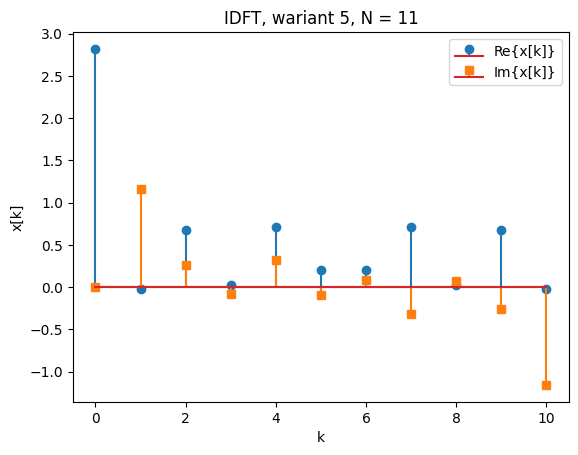

In [6]:
plt.stem(k, x.real, label="Re{x[k]}")
plt.stem(k, x.imag, linefmt="C1-", markerfmt="C1s", label="Im{x[k]}")
plt.title("IDFT, wariant 5, N = 11")
plt.xlabel("k")
plt.ylabel("x[k]")
plt.legend()
plt.show()

## Different values of N
For N < 11 the trailing zeros are removed, for N > 11 zeros are added.

### N = 7

[6 4 4 5 3 4 5]


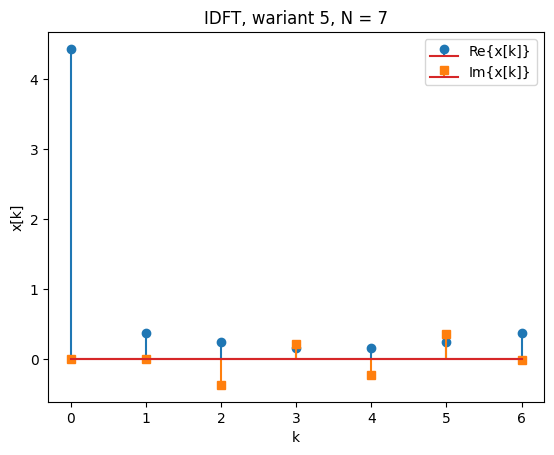

In [7]:
N = 7

X_N = X[:N]
print(X_N)

k = np.arange(N)
mu = np.arange(N)
K = np.outer(k, mu)
W = np.exp(1j * 2 * np.pi / N * K)

x = 1/N * W @ X_N

plt.stem(k, x.real, label="Re{x[k]}")
plt.stem(k, x.imag, linefmt="C1-", markerfmt="C1s", label="Im{x[k]}")
plt.title(f"IDFT, wariant 5, N = {N}")
plt.xlabel("k")
plt.ylabel("x[k]")
plt.legend()
plt.show()

### N = 22

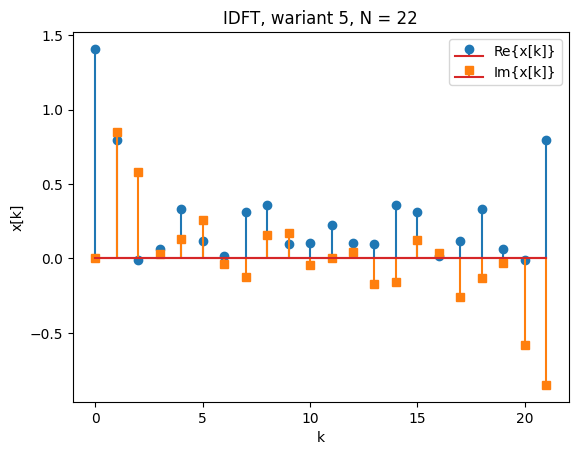

In [8]:
N = 22

X_N = np.concatenate([X, np.zeros(N - N0)])

k = np.arange(N)
mu = np.arange(N)
K = np.outer(k, mu)
W = np.exp(1j * 2 * np.pi / N * K)

x = 1/N * W @ X_N

plt.stem(k, x.real, label="Re{x[k]}")
plt.stem(k, x.imag, linefmt="C1-", markerfmt="C1s", label="Im{x[k]}")
plt.title(f"IDFT, wariant 5, N = {N}")
plt.xlabel("k")
plt.ylabel("x[k]")
plt.legend()
plt.show()

### N = 64

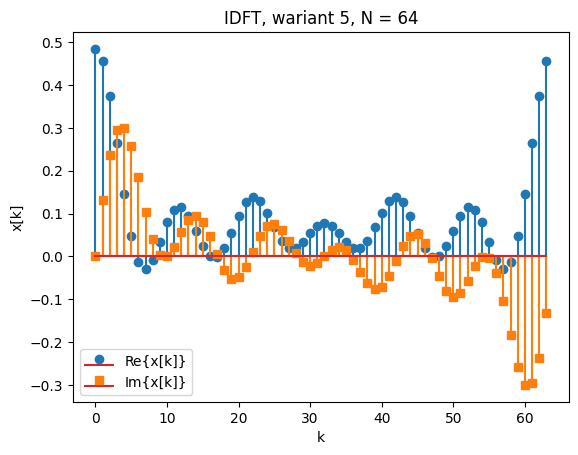

In [9]:
N = 64

X_N = np.concatenate([X, np.zeros(N - N0)])

k = np.arange(N)
mu = np.arange(N)
K = np.outer(k, mu)
W = np.exp(1j * 2 * np.pi / N * K)

x = 1/N * W @ X_N

plt.stem(k, x.real, label="Re{x[k]}")
plt.stem(k, x.imag, linefmt="C1-", markerfmt="C1s", label="Im{x[k]}")
plt.title(f"IDFT, wariant 5, N = {N}")
plt.xlabel("k")
plt.ylabel("x[k]")
plt.legend()
plt.show()

## Conclusions
1. The synthesized signal is complex (it has real and imaginary parts).
2. The real part is symmetric and the imaginary part is antisymmetric, e.g. x[1] = -0.03+1.16j and x[10] = -0.03-1.16j.
3. The first sample is the largest: x[0] = (sum of X) / N = 31 / N.
4. The smallest possible N is 7, because the last non-zero value of X has index 6.
5. A larger N gives more samples and a smoother plot, but a smaller amplitude (N = 7: 4.43, N = 11: 2.82, N = 22: 1.41, N = 64: 0.48).
6. The result is the same as np.fft.ifft.